# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, Concatenate, LeakyReLU, ConvLSTM2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import imagehash
import hashlib

2025-07-12 04:57:31.877913: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752296252.145499      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752296252.228717      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Read Data From File

In [2]:
csv_path = "/kaggle/input/nuero-dataset-balanced/nuero_dataset_balanced/image_labels_balanced.csv"
images_path = "/kaggle/input/nuero-dataset-balanced/nuero_dataset_balanced/images"
model_path = 'final_mobilenet_model.keras'
label_encoder_path = 'label_encoder_classes.npy'

Number of Images
COVID: 1000
Lung_Opacity: 1000
Viral_Pneumonia: 1000
Glioma: 1000
Pituitary: 930
Meningioma: 708
esophagitis: 500
polyps: 500
ulcerative-colitis: 500


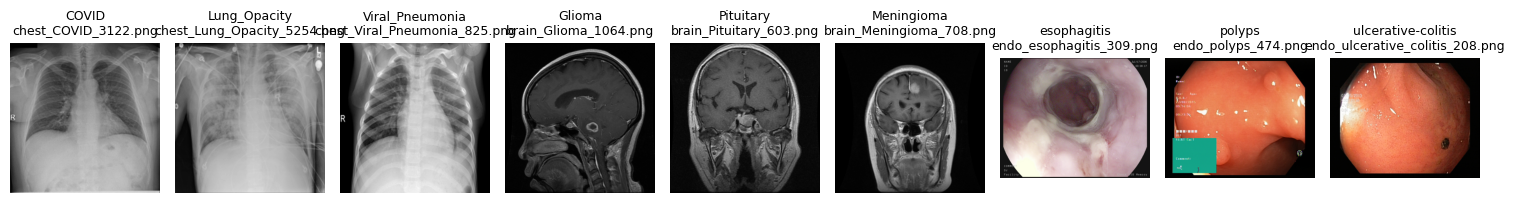

In [3]:
df = pd.read_csv(csv_path)
class_counts = df['label'].value_counts()
classes = class_counts.index

print("Number of Images")
for class_name in classes:
    print(f"{class_name}: {class_counts[class_name]}")

plt.figure(figsize=(15, 4))
for idx, class_name in enumerate(classes):
    class_files = df[df['label'] == class_name]['filename'].tolist()
    sample_file = random.choice(class_files)
    image_path = os.path.join(images_path, sample_file)
    img = Image.open(image_path)
    
    plt.subplot(1, len(classes), idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{class_name}\n{sample_file}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
ahash_dict = {}
phash_dict = {}
md5_dict = {}

for idx, row in df.iterrows():
    image_path = os.path.join(images_path, row['filename'])
    
    try:
        with Image.open(image_path) as img:
           
            ah = str(imagehash.average_hash(img))              # Average Hash
            ahash_dict[ah] = ahash_dict.get(ah, 0) + 1

            ph = str(imagehash.phash(img))                      # Perceptual Hash
            phash_dict[ph] = phash_dict.get(ph, 0) + 1

        with open(image_path, 'rb') as f:                              # MD5 Hash
            md5 = hashlib.md5(f.read()).hexdigest()
            md5_dict[md5] = md5_dict.get(md5, 0) + 1
    except Exception as e:
        print(f"Error processing {image_path}: {e}")

def count_duplicates(hash_dict):
    return sum(1 for count in hash_dict.values() if count > 1)

print("\nDuplicate Hash Summary")
print(f"Average Hash Duplicates: {count_duplicates(ahash_dict)}")
print(f"Perceptual Hash Duplicates: {count_duplicates(phash_dict)}")
print(f"MD5 Hash Duplicates: {count_duplicates(md5_dict)}")



Duplicate Hash Summary
Average Hash Duplicates: 391
Perceptual Hash Duplicates: 42
MD5 Hash Duplicates: 11


# Data Generators

In [4]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])
num_classes = len(label_encoder.classes_)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    # horizontal_flip=True,             # Safe for X-rays and MRIs (not for endoscopy)
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=images_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=images_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 5710 validated image filenames belonging to 9 classes.
Found 1428 validated image filenames belonging to 9 classes.


# The Model

In [5]:
def build_model_with_kernels(kernel_sizes, base_model, num_classes):
    truncate_layer = 'conv_dw_10_relu'
    truncated_output = base_model.get_layer(truncate_layer).output
    truncated_model = Model(inputs=base_model.input, outputs=truncated_output)
    truncated_model.trainable = False

    def modified_inception_block(x, kernel_sizes):
        branch1 = Conv2D(64, (1, 1), padding='same')(x)
        branch1 = LeakyReLU(alpha=0.1)(branch1)

        branch2 = Conv2D(96, (1, 1), padding='same')(x)
        branch2 = LeakyReLU(alpha=0.1)(branch2)
        branch2 = Conv2D(128, kernel_sizes[0], padding='same')(branch2)
        branch2 = LeakyReLU(alpha=0.1)(branch2)

        branch3 = Conv2D(32, (1, 1), padding='same')(x)
        branch3 = LeakyReLU(alpha=0.1)(branch3)
        branch3 = Conv2D(64, kernel_sizes[1], padding='same')(branch3)
        branch3 = LeakyReLU(alpha=0.1)(branch3)

        branch4 = Conv2D(32, (1, 1), padding='same')(x)
        branch4 = LeakyReLU(alpha=0.1)(branch4)
        branch4 = Conv2D(64, kernel_sizes[2], padding='same')(branch4)
        branch4 = LeakyReLU(alpha=0.1)(branch4)

        branch5 = Conv2D(16, (1, 1), padding='same')(x)
        branch5 = LeakyReLU(alpha=0.1)(branch5)
        branch5 = Conv2D(32, kernel_sizes[3], padding='same')(branch5)
        branch5 = LeakyReLU(alpha=0.1)(branch5)

        branch6 = tf.keras.layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
        branch6 = Conv2D(64, (1, 1), padding='same')(branch6)
        branch6 = LeakyReLU(alpha=0.1)(branch6)

        output = Concatenate()([branch1, branch2, branch3, branch4, branch5, branch6])
        return output

    inputs = truncated_model.input
    x = modified_inception_block(truncated_model.output, kernel_sizes)
    x = tf.keras.layers.Reshape((1, x.shape[1], x.shape[2], x.shape[3]))(x)
    x = ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=False)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model




def evaluate_model(model, train_gen, val_gen, epochs=10):
    history = model.fit(train_gen, epochs=epochs, validation_data=val_gen, verbose=0,
                       callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy




def chain_foraging_cyclone_aging(train_gen, val_gen, base_model, num_classes):
    kernel_options = [(3,3), (5,5), (7,7), (11,11)]  
    population_size = 3
    iterations = 4
    epochs_per_eval = 10

    # Initialize population
    population = [random.choices(kernel_options, k=4) for _ in range(population_size)]
    best_solution = None
    best_accuracy = 0.0

    for iteration in range(iterations):
        print(f"Iteration {iteration + 1}/{iterations}")
        scores = []

        for solution in population:
            model = build_model_with_kernels(solution, base_model, num_classes)
            accuracy = evaluate_model(model, train_gen, val_gen, epochs_per_eval)
            scores.append((solution, accuracy))
            print(f"Evaluated kernel sizes {solution}: Validation Accuracy = {accuracy:.4f}")

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_solution = solution

        new_population = []
        for _ in range(population_size):
            parent = random.choice(scores)[0]
            new_solution = [random.choice(kernel_options) if random.random() < 0.3 else k for k in parent]
            new_population.append(new_solution)

        if best_solution:
            refined_solution = best_solution.copy()
            for i in range(len(refined_solution)):
                if random.random() < 0.2:  
                    refined_solution[i] = random.choice(kernel_options)
            new_population.append(refined_solution)

        population = new_population[:population_size]

    print(f"Best kernel sizes: {best_solution}, Best Validation Accuracy: {best_accuracy:.4f}")

    
    return best_solution




base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

optimal_kernel_sizes = chain_foraging_cyclone_aging(train_generator, val_generator, base_model, num_classes)

model = build_model_with_kernels(optimal_kernel_sizes, base_model, num_classes)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_mobilenet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

model.summary()
total_params = model.count_params()
print(f"Total number of parameters in the model: {total_params:,}")

I0000 00:00:1752231168.788197      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iteration 1/4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1752231183.768664      98 service.cc:148] XLA service 0x784c54002fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752231183.769526      98 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1752231184.968250      98 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1752231191.849170      98 device_compiler.h:188] Compiled 

Evaluated kernel sizes [(5, 5), (11, 11), (11, 11), (11, 11)]: Validation Accuracy = 0.1401
Evaluated kernel sizes [(5, 5), (11, 11), (11, 11), (7, 7)]: Validation Accuracy = 0.8908
Evaluated kernel sizes [(3, 3), (11, 11), (11, 11), (5, 5)]: Validation Accuracy = 0.9069
Iteration 2/4
Evaluated kernel sizes [(5, 5), (11, 11), (11, 11), (7, 7)]: Validation Accuracy = 0.1401
Evaluated kernel sizes [(5, 5), (11, 11), (11, 11), (11, 11)]: Validation Accuracy = 0.1401
Evaluated kernel sizes [(5, 5), (11, 11), (11, 11), (11, 11)]: Validation Accuracy = 0.8732
Iteration 3/4
Evaluated kernel sizes [(11, 11), (11, 11), (11, 11), (11, 11)]: Validation Accuracy = 0.8466
Evaluated kernel sizes [(5, 5), (11, 11), (11, 11), (7, 7)]: Validation Accuracy = 0.9125
Evaluated kernel sizes [(7, 7), (11, 11), (5, 5), (7, 7)]: Validation Accuracy = 0.1401
Iteration 4/4
Evaluated kernel sizes [(5, 5), (11, 11), (11, 11), (11, 11)]: Validation Accuracy = 0.8368
Evaluated kernel sizes [(3, 3), (11, 11), (11, 1

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 32)   │            128 │ conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1                 │ (None, 112, 112, 32)   │            288 │ conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_bn              │ (None, 112, 112, 32)   │            128 │ conv_dw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_relu (ReLU)     │ (None, 112, 112, 32)   │              0 │ conv_dw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1 (Conv2D)        │ (None, 112, 112, 64)   │          2,048 │ conv_dw_1_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_bn              │ (None, 112, 112, 64)   │            256 │ conv_pw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_relu (ReLU)     │ (None, 112, 112, 64)   │              0 │ conv_pw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pad_2                │ (None, 113, 113, 64)   │              0 │ conv_pw_1_relu[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2                 │ (None, 56, 56, 64)     │            576 │ conv_pad_2[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_bn              │ (None, 56, 56, 64)     │            256 │ conv_dw_2[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_relu (ReLU)     │ (None, 56, 56, 64)     │              0 │ conv_dw_2_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2 (Conv2D)        │ (None, 56, 56, 128)    │          8,192 │ conv_dw_2_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2_bn              │ (None, 56, 56, 128)    │            512 │ conv_pw_2[0][0]        │
│ (BatchNormalization) 

 Total params: 3,779,097 (14.42 MB)

 Trainable params: 2,686,297 (10.25 MB)

 Non-trainable params: 1,092,800 (4.17 MB)

Total number of parameters in the model: 3,779,097


# Train

In [7]:
history = model.fit(
    train_generator,
    epochs=32,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

model.save(model_path)
np.save(label_encoder_path, label_encoder.classes_)

Epoch 1/32
179/179 ━━━━━━━━━━━━━━━━━━━━ 127s 623ms/step - accuracy: 0.1334 - loss: 2.1722 - val_accuracy: 0.2955 - val_loss: 1.4704 - learning_rate: 0.0010
Epoch 2/32
179/179 ━━━━━━━━━━━━━━━━━━━━ 104s 583ms/step - accuracy: 0.4176 - loss: 1.2121 - val_accuracy: 0.5812 - val_loss: 0.7685 - learning_rate: 0.0010
Epoch 3/32
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 577ms/step - accuracy: 0.6124 - loss: 0.7582 - val_accuracy: 0.5364 - val_loss: 0.7963 - learning_rate: 0.0010
Epoch 4/32
179/179 ━━━━━━━━━━━━━━━━━━━━ 104s 580ms/step - accuracy: 0.6363 - loss: 0.6800 - val_accuracy: 0.6709 - val_loss: 0.6072 - learning_rate: 0.0010
Epoch 5/32
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 577ms/step - accuracy: 0.6869 - loss: 0.5873 - val_accuracy: 0.6611 - val_loss: 0.6613 - learning_rate: 0.0010
Epoch 6/32
179/179 ━━━━━━━━━━━━━━━━━━━━ 104s 579ms/step - accuracy: 0.7325 - loss: 0.5422 - val_accuracy: 0.6856 - val_loss: 0.7591 - learning_rate: 0.0010
Epoch 7/32
179/179 ━━━━━━━━━━━━━━━━━━━━ 105s 589ms/step - accura

# Evaluation

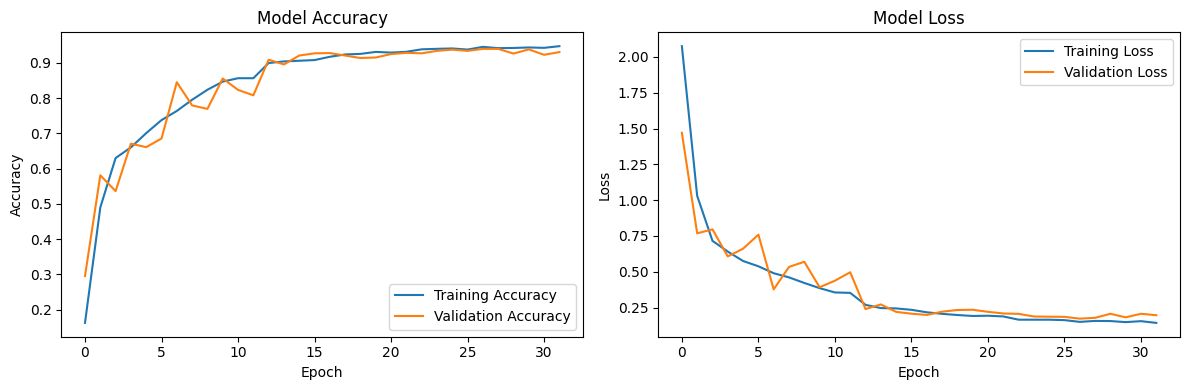

Found 1428 validated image filenames belonging to 9 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - accuracy: 0.9401 - loss: 0.1628
Test Loss: 0.1728
Test Accuracy: 0.9398
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 290ms/step


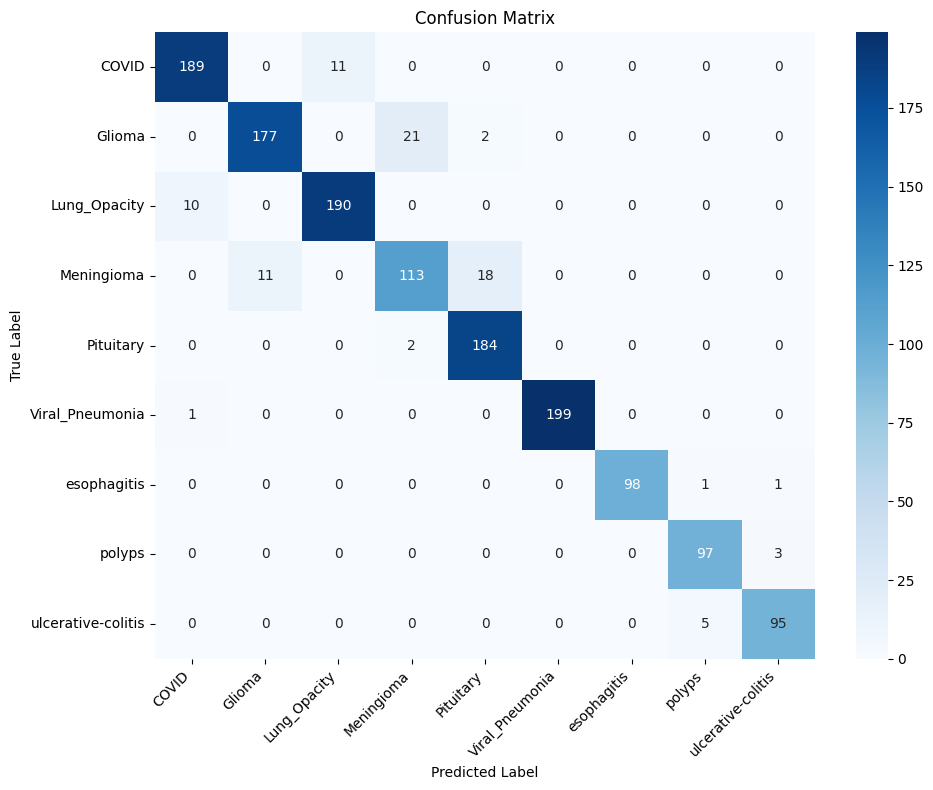


Classification Report:
                    precision    recall  f1-score   support

             COVID       0.94      0.94      0.94       200
            Glioma       0.94      0.89      0.91       200
      Lung_Opacity       0.95      0.95      0.95       200
        Meningioma       0.83      0.80      0.81       142
         Pituitary       0.90      0.99      0.94       186
   Viral_Pneumonia       1.00      0.99      1.00       200
       esophagitis       1.00      0.98      0.99       100
            polyps       0.94      0.97      0.96       100
ulcerative-colitis       0.96      0.95      0.95       100

          accuracy                           0.94      1428
         macro avg       0.94      0.94      0.94      1428
      weighted avg       0.94      0.94      0.94      1428



In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=images_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

model = tf.keras.models.load_model(model_path)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=label_encoder.classes_))